In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

customer_spending  = pd.read_parquet("../data/processed/customer_spending.parquet")
top_categories     = pd.read_parquet("../data/processed/top_categories.parquet")
monthly_trends     = pd.read_parquet("../data/processed/monthly_trends.parquet")
customer_segments  = pd.read_parquet("../data/processed/customer_segments.parquet")

BRL = lambda x, _: f"R${x/1000:.0f}k" if x >= 1000 else f"R${x:.0f}"

# ── 1. Customer Spending Patterns ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Customer Spending Patterns", fontsize=15, fontweight="bold", y=1.02)

ax = axes[0]
ax.hist(
    customer_spending["total_spend"].clip(upper=customer_spending["total_spend"].quantile(0.99)),
    bins=50, color="#4477AA", edgecolor="white", linewidth=0.4,
)
ax.set_title("Total spend distribution")
ax.set_xlabel("Total spend (R$)")
ax.set_ylabel("Customers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))

ax = axes[1]
order_counts = customer_spending["order_count"].value_counts().sort_index().head(10)
ax.bar(order_counts.index.astype(str), order_counts.values, color="#66AADD", edgecolor="white")
ax.set_title("Orders per customer")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Customers")

ax = axes[2]
sample = customer_spending.sample(min(3000, len(customer_spending)), random_state=42)
ax.scatter(
    sample["avg_order_value"].clip(upper=customer_spending["avg_order_value"].quantile(0.99)),
    sample["total_spend"].clip(upper=customer_spending["total_spend"].quantile(0.99)),
    alpha=0.3, s=10, color="#4477AA",
)
ax.set_title("Avg order value vs total spend")
ax.set_xlabel("Avg order value (R$)")
ax.set_ylabel("Total spend (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(BRL))

plt.tight_layout()
plt.show()

# ── 2. Top Categories Performance ─────────────────────────────────────────────
top_n = top_categories.nlargest(12, "total_orders").sort_values("total_orders")
colors = sns.color_palette("Blues_r", len(top_n))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Top Categories Performance", fontsize=15, fontweight="bold", y=1.02)

ax = axes[0]
bars = ax.barh(top_n["category_name"], top_n["total_orders"], color=colors)
ax.set_title("Orders by category (top 12)")
ax.set_xlabel("Order count")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=8)
ax.set_xlim(right=top_n["total_orders"].max() * 1.15)

ax = axes[1]
ax.scatter(
    top_n["total_revenue"], top_n["avg_review_score"],
    s=top_n["total_orders"] / top_n["total_orders"].max() * 800,
    c=range(len(top_n)), cmap="Blues", alpha=0.75,
    edgecolors="#333", linewidth=0.5,
)
for _, row in top_n.iterrows():
    ax.annotate(row["category_name"], (row["total_revenue"], row["avg_review_score"]),
                fontsize=7.5, ha="left", va="bottom", xytext=(4, 4), textcoords="offset points")
ax.set_title("Revenue vs review score\n(bubble size = order volume)")
ax.set_xlabel("Total revenue (R$)")
ax.set_ylabel("Avg review score")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))
ax.set_ylim(1, 5.2)

plt.tight_layout()
plt.show()

# ── 3. Monthly Trends ─────────────────────────────────────────────────────────
monthly_trends["year_month"] = pd.to_datetime(monthly_trends["year_month"])
monthly_trends = monthly_trends.sort_values("year_month")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Monthly Trends Over Time", fontsize=15, fontweight="bold")

ax = axes[0]
ax.fill_between(monthly_trends["year_month"], monthly_trends["order_count"], alpha=0.15, color="#4477AA")
ax.plot(monthly_trends["year_month"], monthly_trends["order_count"], color="#4477AA", linewidth=2)
ax.set_title("Monthly order volume")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax = axes[1]
ax.fill_between(monthly_trends["year_month"], monthly_trends["revenue"], alpha=0.15, color="#44AA77")
ax.plot(monthly_trends["year_month"], monthly_trends["revenue"], color="#44AA77", linewidth=2)
ax.set_title("Monthly revenue")
ax.set_ylabel("Revenue (R$)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

# ── 4. Customer Segments ──────────────────────────────────────────────────────
seg = customer_segments.sort_values("customer_count", ascending=False)
palette = sns.color_palette("Set2", len(seg))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Customer Segments Breakdown", fontsize=15, fontweight="bold", y=1.02)

ax = axes[0]
ax.pie(
    seg["customer_count"], labels=seg["segment"], autopct="%1.1f%%",
    startangle=140, colors=palette,
    wedgeprops=dict(width=0.55, edgecolor="white"), pctdistance=0.75,
)
ax.set_title("Customer count by segment")

ax = axes[1]
bars = ax.bar(seg["segment"], seg["avg_spend"], color=palette, edgecolor="white")
ax.set_title("Avg spend per segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Avg spend (R$)")
ax.bar_label(bars, fmt="R${:,.0f}", padding=4, fontsize=8)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right")
ax.set_ylim(top=seg["avg_spend"].max() * 1.2)

ax = axes[2]
seg["total_revenue"] = seg["customer_count"] * seg["avg_spend"]
seg_sorted = seg.sort_values("total_revenue")
ax.barh(seg_sorted["segment"], seg_sorted["total_revenue"], color=palette[::-1], edgecolor="white")
ax.set_title("Total revenue by segment")
ax.set_xlabel("Revenue (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/customer_spending.parquet'

In [1]:
import os
os.listdir("../data/processed/")

FileNotFoundError: [WinError 3] Määritettyä polkua ei löydy: '../data/processed/'

In [2]:
import os
os.getcwd()

'c:\\Users\\NadjaAhonen\\AppData\\Local\\Programs\\Microsoft VS Code'

In [3]:
import os
for root, dirs, files in os.walk("C:/Users/NadjaAhonen"):
    for file in files:
        if file.endswith(".parquet"):
            print(os.path.join(root, file))

C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.all-named-index.parquet
C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.column-metadata-handling.parquet
C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.parquet
C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.some-named-index.parquet
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.all-named-index.parquet
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.column-metadata-handling.parquet
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.parquet
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.some-named-index.parquet


In [4]:
import os
for file in os.listdir(path):
    print(file)

NameError: name 'path' is not defined

In [5]:
import kagglehub
import os

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

for file in os.listdir(path):
    print(file)

ModuleNotFoundError: No module named 'kagglehub'

In [6]:
import os
for root, dirs, files in os.walk("C:/Users/NadjaAhonen"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyspark\python\lib\py4j-0.10.9.9-src.zip
C:/Users/NadjaAhonen\.venv\Lib\site-packages\pyspark\python\lib\pyspark.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\python\lib\py4j-0.10.9.9-src.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyspark\python\lib\pyspark.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\test\archivetestdata\zipdir.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\test\archivetestdata\zipdir_backslash.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\test\archivetestdata\zip_cp437_header.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\test\test_importlib\namespace_pkgs\missing_directory.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\test\test_importlib\namespace_pkgs\nested_portion1.zip
C:/Users/NadjaAhonen\AppData\Local\Programs\Python\Pyth

In [7]:
import zipfile
import pandas as pd
import os

zip_path = "C:/Users/NadjaAhonen/Downloads/archive.zip"
extract_path = "C:/Users/NadjaAhonen/Downloads/olist/"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)
    print(z.namelist())

['02_spark_processing.ipynb']


In [8]:
import sys
!{sys.executable} -m pip install kagglehub

import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(path)

import os
for file in os.listdir(path):
    print(file)

  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl (154 kB)
Using cached requests-2.33.1-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl (158 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)

   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\NadjaAhonen\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 42.6M/42.6M [00:01<00:00, 25.7MB/s]

Extracting files...


C:\Users\NadjaAhonen\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


Data loaded!


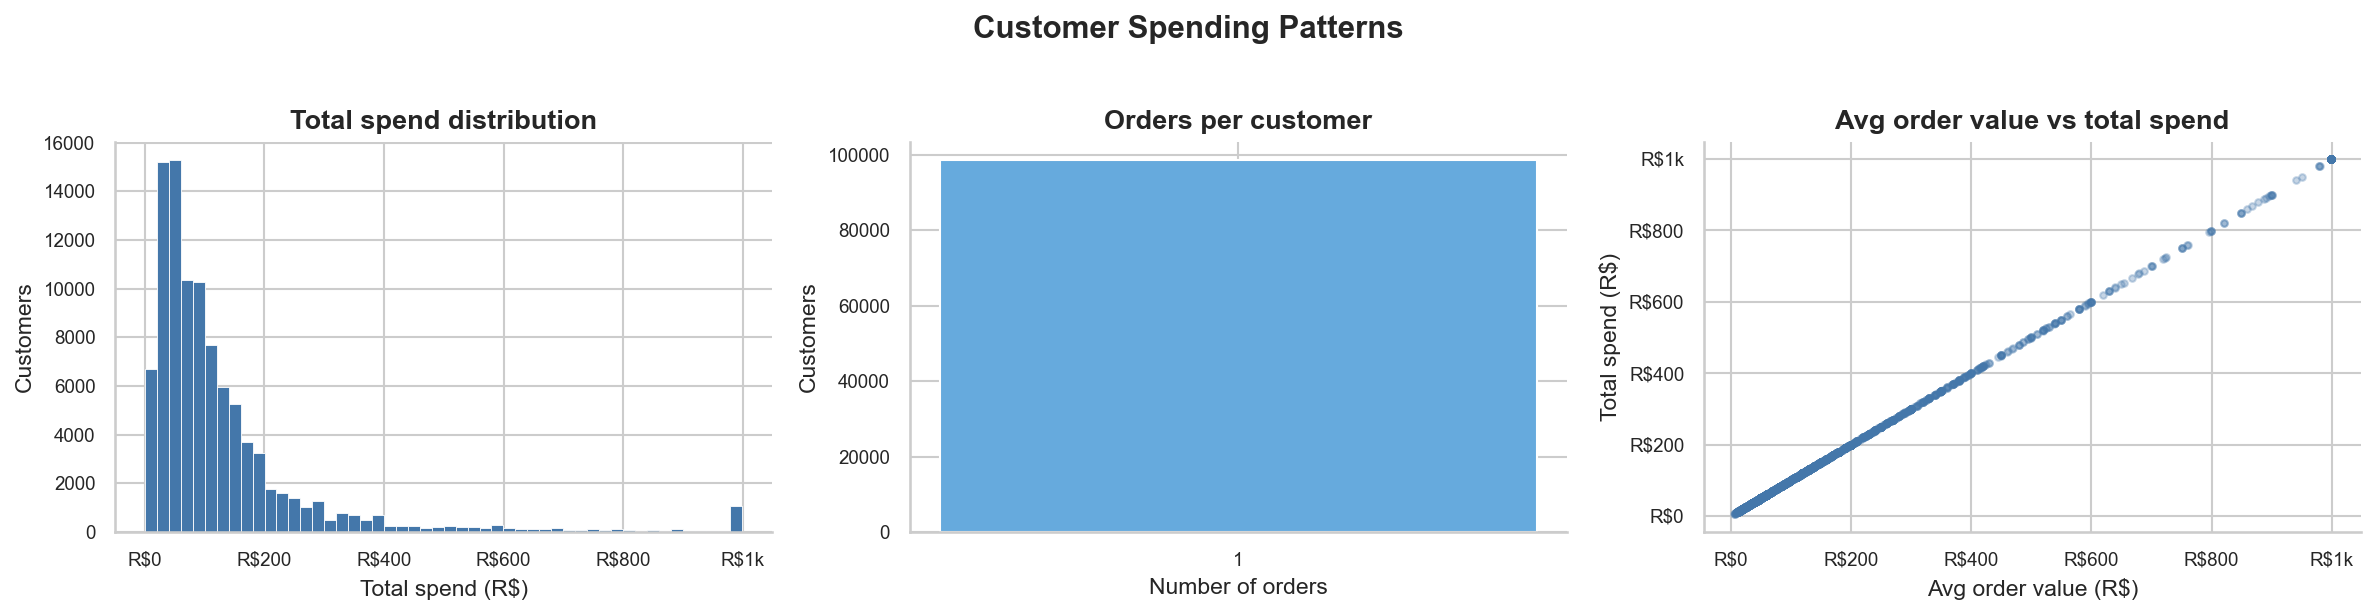

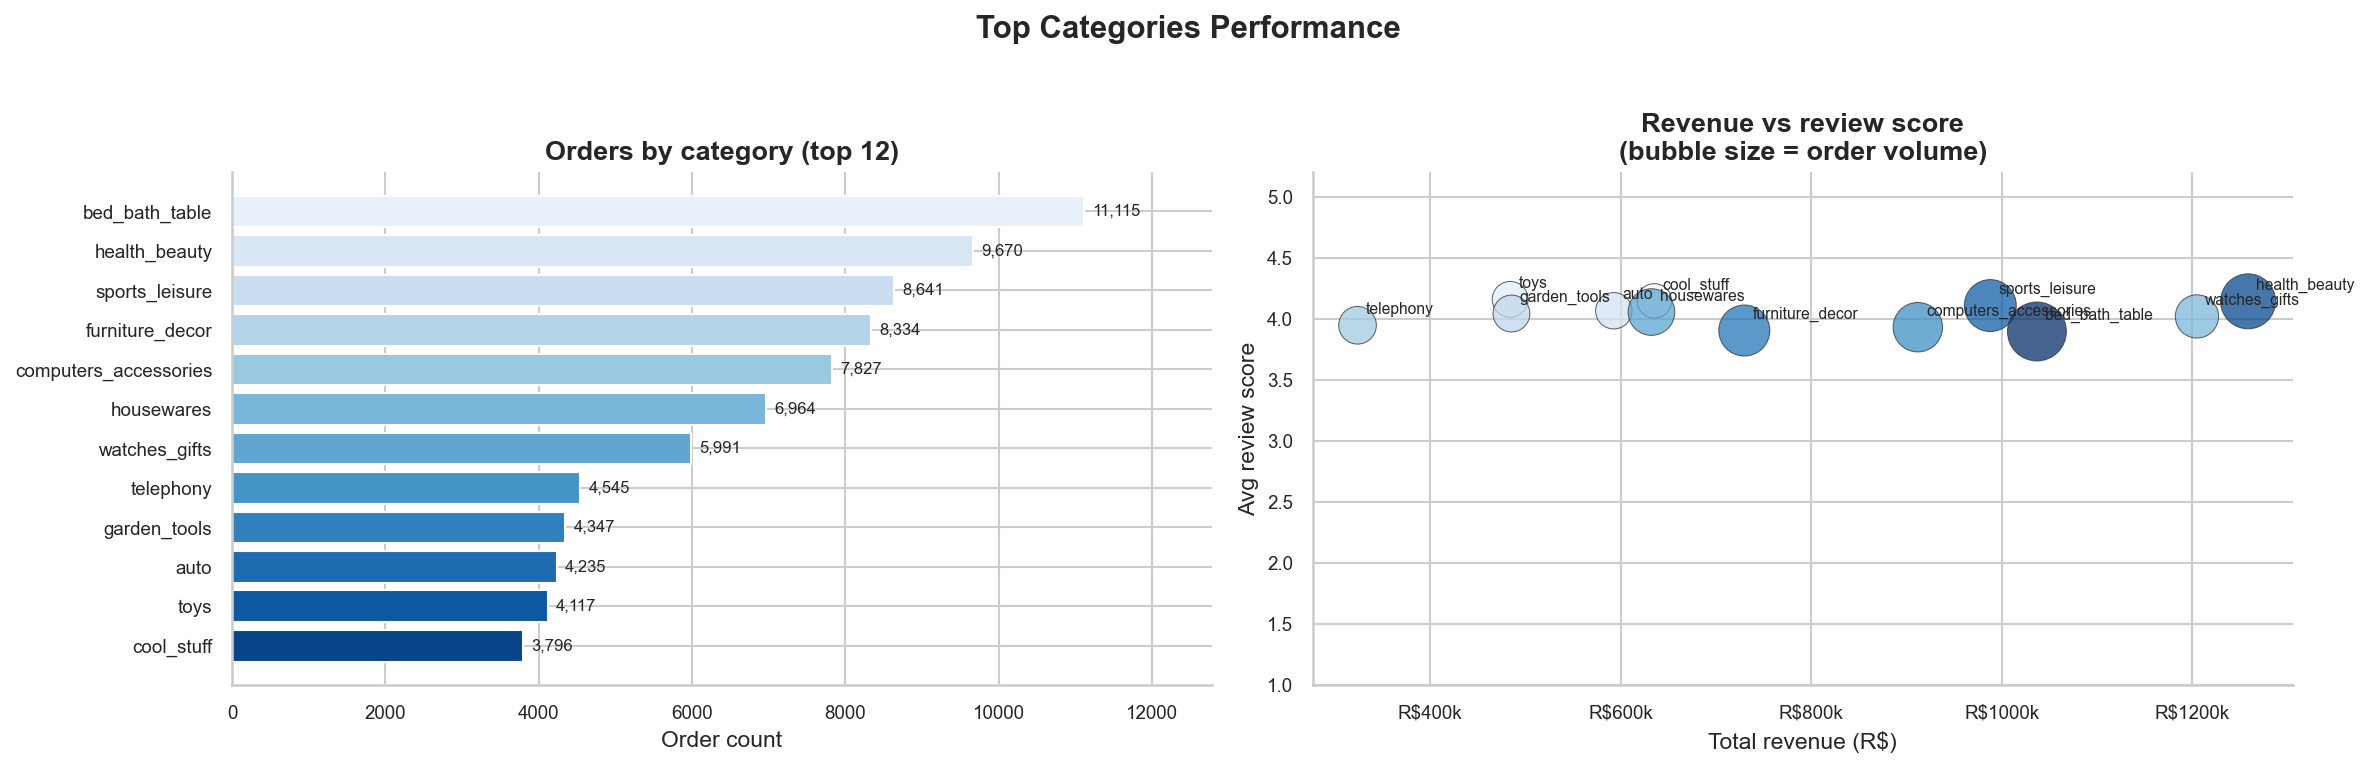

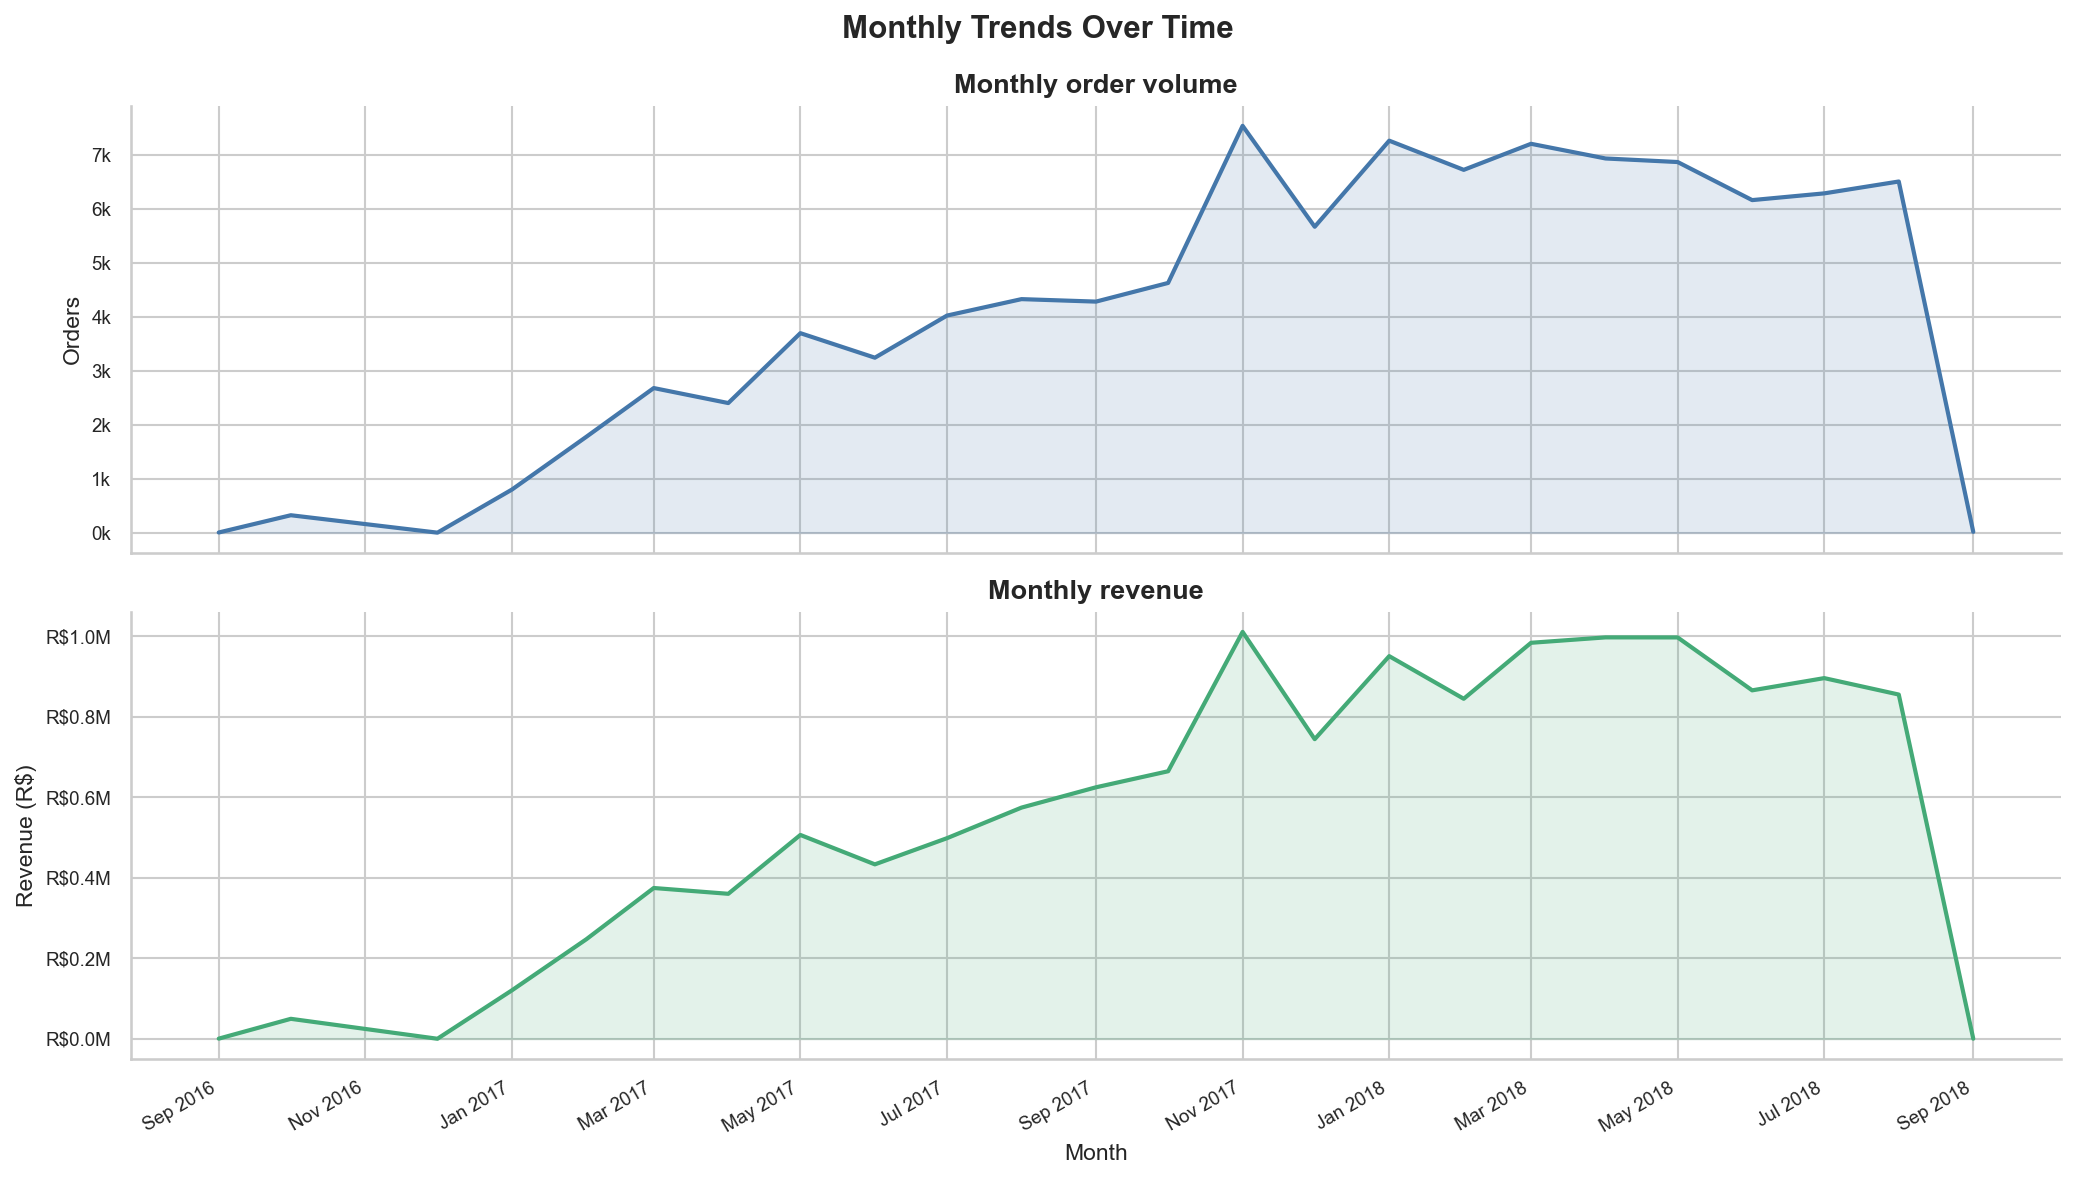

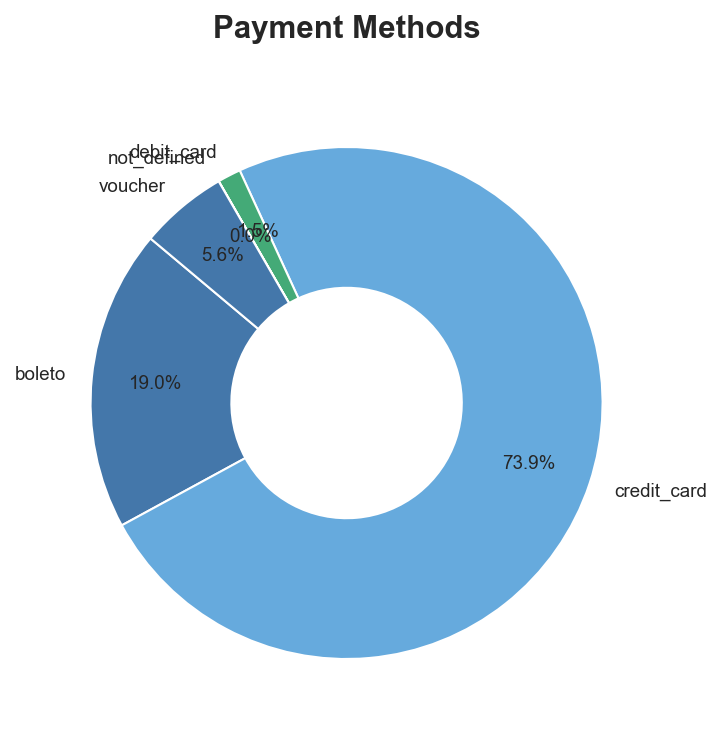

All charts done!


In [9]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ── Load CSVs ──────────────────────────────────────────────────────────────────
data_path = r"C:\Users\NadjaAhonen\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2"

orders    = pd.read_csv(f"{data_path}/olist_orders_dataset.csv")
items     = pd.read_csv(f"{data_path}/olist_order_items_dataset.csv")
payments  = pd.read_csv(f"{data_path}/olist_order_payments_dataset.csv")
reviews   = pd.read_csv(f"{data_path}/olist_order_reviews_dataset.csv")
products  = pd.read_csv(f"{data_path}/olist_products_dataset.csv")
customers = pd.read_csv(f"{data_path}/olist_customers_dataset.csv")
sellers   = pd.read_csv(f"{data_path}/olist_sellers_dataset.csv")
transl    = pd.read_csv(f"{data_path}/product_category_name_translation.csv")

print("Data loaded!")

# ── Prepare data ───────────────────────────────────────────────────────────────
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])

# Customer spending
order_value = items.groupby("order_id")["price"].sum().reset_index(name="order_value")
order_value = order_value.merge(orders[["order_id","customer_id"]], on="order_id")
customer_spending = order_value.groupby("customer_id").agg(
    total_spend=("order_value","sum"),
    order_count=("order_id","count"),
    avg_order_value=("order_value","mean")
).reset_index()

# Top categories
products = products.merge(transl, on="product_category_name", how="left")
items_prod = items.merge(products[["product_id","product_category_name_english"]], on="product_id", how="left")
items_orders = items_prod.merge(orders[["order_id","order_status"]], on="order_id")
items_reviews = items_prod.merge(reviews[["order_id","review_score"]], on="order_id", how="left")
top_categories = items_prod.groupby("product_category_name_english").agg(
    total_orders=("order_id","count"),
    total_revenue=("price","sum")
).reset_index()
rev_scores = items_reviews.groupby("product_category_name_english")["review_score"].mean().reset_index(name="avg_review_score")
top_categories = top_categories.merge(rev_scores, on="product_category_name_english", how="left")
top_categories = top_categories.dropna(subset=["product_category_name_english"])

# Monthly trends
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
monthly_orders = orders.groupby("year_month").size().reset_index(name="order_count")
monthly_revenue = order_value.merge(orders[["order_id","year_month"]], on="order_id")
monthly_revenue = monthly_revenue.groupby("year_month")["order_value"].sum().reset_index(name="revenue")
monthly_trends = monthly_orders.merge(monthly_revenue, on="year_month")
monthly_trends["year_month"] = pd.to_datetime(monthly_trends["year_month"])
monthly_trends = monthly_trends.sort_values("year_month")

# Payment methods
payment_types = payments.groupby("payment_type")["order_id"].count().reset_index(name="count")

BRL = lambda x, _: f"R${x/1000:.0f}k" if x >= 1000 else f"R${x:.0f}"


# ══════════════════════════════════════════════════════════════════════════════
# 1. CUSTOMER SPENDING PATTERNS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Customer Spending Patterns", fontsize=15, fontweight="bold", y=1.02)

ax = axes[0]
ax.hist(
    customer_spending["total_spend"].clip(upper=customer_spending["total_spend"].quantile(0.99)),
    bins=50, color="#4477AA", edgecolor="white", linewidth=0.4,
)
ax.set_title("Total spend distribution")
ax.set_xlabel("Total spend (R$)")
ax.set_ylabel("Customers")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))

ax = axes[1]
order_counts = customer_spending["order_count"].value_counts().sort_index().head(10)
ax.bar(order_counts.index.astype(str), order_counts.values, color="#66AADD", edgecolor="white")
ax.set_title("Orders per customer")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Customers")

ax = axes[2]
sample = customer_spending.sample(min(3000, len(customer_spending)), random_state=42)
ax.scatter(
    sample["avg_order_value"].clip(upper=customer_spending["avg_order_value"].quantile(0.99)),
    sample["total_spend"].clip(upper=customer_spending["total_spend"].quantile(0.99)),
    alpha=0.3, s=10, color="#4477AA",
)
ax.set_title("Avg order value vs total spend")
ax.set_xlabel("Avg order value (R$)")
ax.set_ylabel("Total spend (R$)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(BRL))

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2. TOP CATEGORIES
# ══════════════════════════════════════════════════════════════════════════════
top_n = top_categories.nlargest(12, "total_orders").sort_values("total_orders")
colors = sns.color_palette("Blues_r", len(top_n))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Top Categories Performance", fontsize=15, fontweight="bold", y=1.02)

ax = axes[0]
bars = ax.barh(top_n["product_category_name_english"], top_n["total_orders"], color=colors)
ax.set_title("Orders by category (top 12)")
ax.set_xlabel("Order count")
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=8)
ax.set_xlim(right=top_n["total_orders"].max() * 1.15)

ax = axes[1]
ax.scatter(
    top_n["total_revenue"], top_n["avg_review_score"],
    s=top_n["total_orders"] / top_n["total_orders"].max() * 800,
    c=range(len(top_n)), cmap="Blues", alpha=0.75,
    edgecolors="#333", linewidth=0.5,
)
for _, row in top_n.iterrows():
    ax.annotate(row["product_category_name_english"],
                (row["total_revenue"], row["avg_review_score"]),
                fontsize=7.5, ha="left", va="bottom", xytext=(4, 4), textcoords="offset points")
ax.set_title("Revenue vs review score\n(bubble size = order volume)")
ax.set_xlabel("Total revenue (R$)")
ax.set_ylabel("Avg review score")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(BRL))
ax.set_ylim(1, 5.2)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 3. MONTHLY TRENDS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Monthly Trends Over Time", fontsize=15, fontweight="bold")

ax = axes[0]
ax.fill_between(monthly_trends["year_month"], monthly_trends["order_count"], alpha=0.15, color="#4477AA")
ax.plot(monthly_trends["year_month"], monthly_trends["order_count"], color="#4477AA", linewidth=2)
ax.set_title("Monthly order volume")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

ax = axes[1]
ax.fill_between(monthly_trends["year_month"], monthly_trends["revenue"], alpha=0.15, color="#44AA77")
ax.plot(monthly_trends["year_month"], monthly_trends["revenue"], color="#44AA77", linewidth=2)
ax.set_title("Monthly revenue")
ax.set_ylabel("Revenue (R$)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 4. PAYMENT METHODS
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Payment Methods", fontsize=15, fontweight="bold")

colors_pay = ["#4477AA", "#66AADD", "#44AA77", "#AADDBB"]
wedges, texts, autotexts = ax.pie(
    payment_types["count"],
    labels=payment_types["payment_type"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors_pay,
    wedgeprops=dict(width=0.55, edgecolor="white"),
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)

plt.tight_layout()
plt.show()

print("All charts done!")

In [10]:
plt.tight_layout()
plt.savefig("C:/Users/NadjaAhonen/Desktop/chart1_spending.png", bbox_inches="tight")
plt.show()

<Figure size 960x720 with 0 Axes>